# test_challenge 데이터 읽기 — 공식 fastMRI test (prospective 언더샘플, GT 없음)

`knee/test_challenge` 는 fastMRI 공식 챌린지 세트로:
- k-space가 **이미 prospective하게 언더샘플** (위상 라인 일부만 획득, ~7.4×)
- 저장 키: `kspace` (멀티코일, readout만 320으로 crop·위상 native) + `sens_map`(ESPIRiT) + `mask`(실제 획득 패턴)
- **`rss`(GT) 없음** → SSIM/PSNR(진짜 GT 기준)는 계산 불가, 정성/CG-SENSE reference만 가능

In [1]:
import os, sys, glob
sys.path.insert(0, '/home/sonwonjun/research/MRRecon/code')
import numpy as np, h5py, torch
import matplotlib.pyplot as plt
from mrrecon.data.transforms import sense_combine_np, rss_np
from mrrecon.models.sense import cg_sense_recon

DIR='/mnt/d/research/MRRecon/knee/test_challenge'
files=sorted(glob.glob(DIR+'/*.h5'))
subj=len({os.path.basename(f).rsplit('_',1)[0] for f in files})
print(f'{len(files)} slices from {subj} volumes')
# 한 슬라이스 로드
fp=files[len(files)//2]
with h5py.File(fp,'r') as h:
    print('keys:', list(h.keys()))
    kspace=h['kspace'][:]; sens=h['sens_map'][:]
    mask=h['mask'][:] if 'mask' in h else None
    has_rss='rss' in h
C_,H,W=kspace.shape
acq=int(mask.sum()) if mask is not None else int((np.abs(kspace).sum((0,1))>0).sum())
print(f'file {os.path.basename(fp)} | kspace {kspace.shape} | sens {sens.shape} | mask {None if mask is None else mask.shape}')
print(f'acquired phase lines: {acq}/{W}  (~{W/acq:.1f}x)  | rss(GT) present: {has_rss}')

4092 slices from 118 volumes
keys: ['kspace', 'mask', 'sens_map']
file file1001187_011.h5 | kspace (15, 320, 368) | sens (15, 320, 368) | mask (368,)
acquired phase lines: 90/368  (~4.1x)  | rss(GT) present: False


## 1. 마스크 / k-space — 언더샘플 확인
위상축(ky)에서 일부 라인만 획득됨. 중앙 ACS(저주파)는 채워져 있어 감도맵 추정 가능.

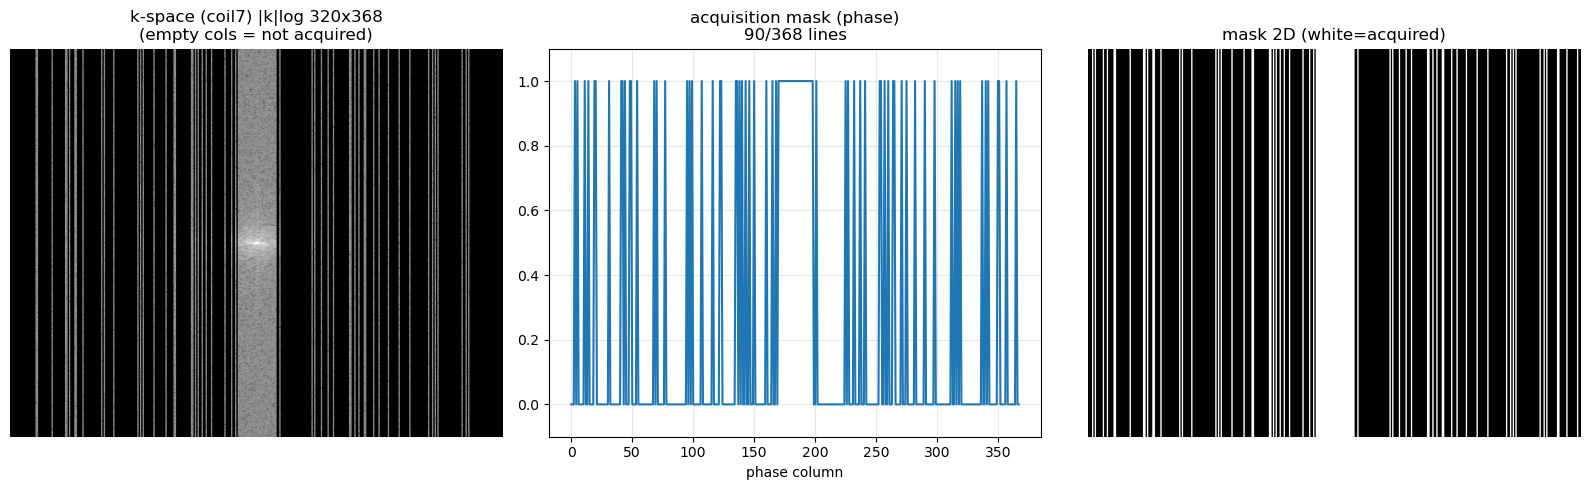

중앙 ACS(연속 획득): 170..198 = 29 lines


In [2]:
om = mask.astype(np.float32) if mask is not None else (np.abs(kspace).sum((0,1))>0).astype(np.float32)
fig,ax=plt.subplots(1,3,figsize=(16,5))
ax[0].imshow(np.log(np.abs(kspace[7])+1e-9),cmap='gray',aspect='auto'); ax[0].set_title(f'k-space (coil7) |k|log {H}x{W}\n(empty cols = not acquired)'); ax[0].axis('off')
ax[1].plot(om); ax[1].set_title(f'acquisition mask (phase)\n{acq}/{W} lines'); ax[1].set_xlabel('phase column'); ax[1].set_ylim(-0.1,1.1); ax[1].grid(alpha=0.3)
ax[2].imshow(np.broadcast_to(om[None,:],(H,W)),cmap='gray',aspect='auto'); ax[2].set_title('mask 2D (white=acquired)'); ax[2].axis('off')
plt.tight_layout(); plt.show()
# ACS 중앙 fully-sampled 블록
c=W//2; l=c
while l>0 and om[l-1]: l-=1
r=c
while r<W-1 and om[r+1]: r+=1
print(f'중앙 ACS(연속 획득): {l}..{r} = {r-l+1} lines')

## 2. 감도맵 + 복원 (GT 없음)
- **SENSE combine**(획득 k-space) = aliased zero-filled (입력, GT 아님)
- **CG-SENSE 복원** = 감도맵으로 aliasing 푼 고전 병렬영상 reference (절대 GT는 아님)

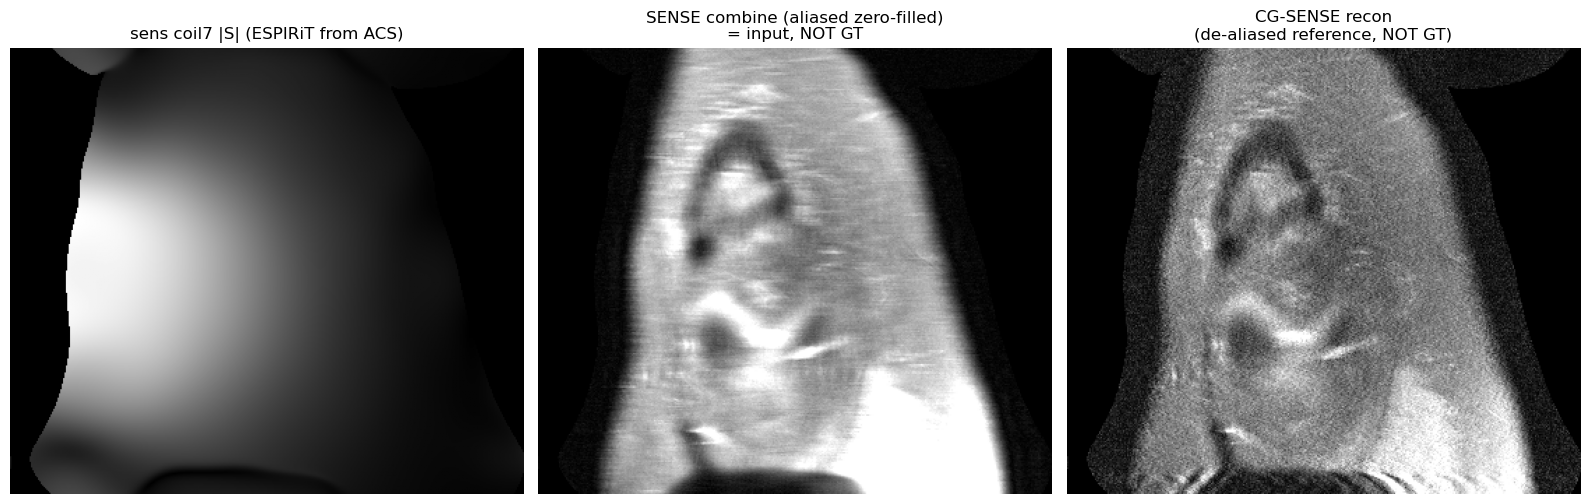

In [3]:
omega=np.broadcast_to(om[None,:],(H,W)).copy()
zf=np.abs(sense_combine_np(kspace,sens))                       # aliased zero-filled
cg=np.abs(cg_sense_recon(kspace,sens,omega,lam=1e-2,cg_iter=30,device='cpu').cpu().numpy())
fig,ax=plt.subplots(1,3,figsize=(16,5))
ax[0].imshow(np.abs(sens[7]),cmap='gray'); ax[0].set_title('sens coil7 |S| (ESPIRiT from ACS)'); ax[0].axis('off')
ax[1].imshow(zf,cmap='gray',vmax=0.6*zf.max()); ax[1].set_title('SENSE combine (aliased zero-filled)\n= input, NOT GT'); ax[1].axis('off')
ax[2].imshow(cg,cmap='gray',vmax=0.6*cg.max()); ax[2].set_title('CG-SENSE recon\n(de-aliased reference, NOT GT)'); ax[2].axis('off')
plt.tight_layout(); plt.show()

## 3. 여러 슬라이스 미리보기 (CG-SENSE)

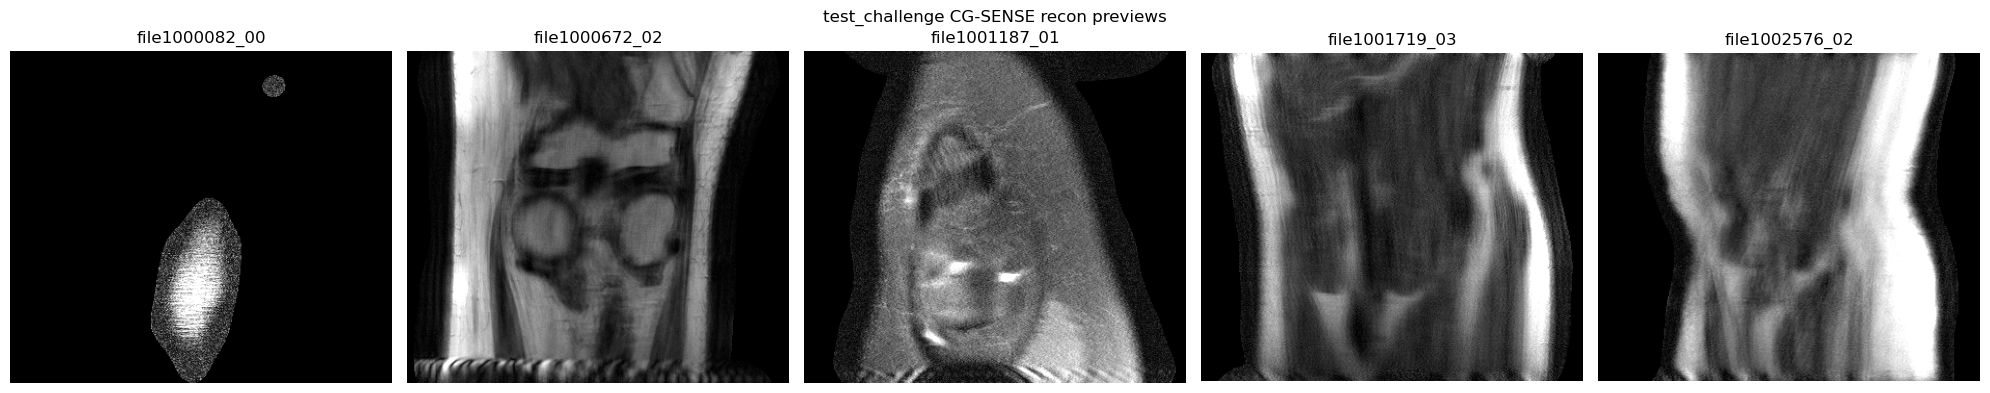

In [4]:
idxs=np.linspace(0,len(files)-1,5).astype(int)
fig,ax=plt.subplots(1,5,figsize=(20,4))
for a,i in zip(ax,idxs):
    with h5py.File(files[i],'r') as h: k=h['kspace'][:]; s=h['sens_map'][:]; m=h['mask'][:]
    o=np.broadcast_to(m.astype(np.float32)[None,:],k.shape[1:]).copy()
    rec=np.abs(cg_sense_recon(k,s,o,lam=1e-2,cg_iter=20,device='cpu').cpu().numpy())
    a.imshow(rec,cmap='gray',vmax=0.6*rec.max()); a.set_title(os.path.basename(files[i])[:14]); a.axis('off')
plt.suptitle('test_challenge CG-SENSE recon previews'); plt.tight_layout(); plt.show()

**정리**
- test_challenge = **prospective 언더샘플(~7.4×), GT 없음** → SSIM/PSNR(진짜 GT) 계산 불가
- 저장: `kspace`(멀티코일, 320×native) + `sens_map` + `mask`. `rss` 없음
- 정량은 test/val(fully-sampled)에서, test_challenge는 **정성 + CG-SENSE reference**
- 모델 추론: `python -m mrrecon.eval --method ssdu --run runs/... --split test_challenge --reference cgsense`